# Gold (XAU/USD) Next-Day Price Forecasting: Naive vs ARIMA vs XGBoost vs LSTM

**Author:** David Kurniawan · **Domain:** Finance / Economics · **Task:** Time-series forecasting (regression)

This notebook is the executable companion of the report `reports/laporan.md`. Every stage below appears
**in the same order** in the report: Project Domain → Business Understanding → Data Understanding →
Data Preparation → Modeling → Evaluation.

It is self-contained (no imports from the `src/` package) so it can be run as-is in Jupyter, VS Code or Google Colab.

## 1. Project Domain

Gold is a global safe-haven asset, an inflation hedge and a major central-bank reserve asset. Its price
affects portfolio allocation, jewellery and mining businesses, and — for Indonesia — domestic gold prices
(e.g., Antam bullion) that track XAU/USD converted to rupiah. Accurate short-horizon forecasts support
hedging and risk-management decisions.

The academic literature is split. Some studies report large gains for LSTM over ARIMA on financial series
(Siami-Namini & Namin, 2018; Fischer & Krauss, 2018), while the M3-based study of Makridakis et al. (2018)
found statistical methods more accurate and far cheaper than machine-learning methods. This project tests,
on one concrete series and modest hardware (RTX 4050, 6 GB), **whether the extra complexity of ML/DL models is
justified over a naive baseline and ARIMA**.

## 2. Business Understanding

### Problem Statements
1. How accurately can the next trading day's gold closing price be forecast from its own history?
2. Do machine-learning (XGBoost) and deep-learning (LSTM) models deliver a statistically meaningful
   improvement over a naive random-walk forecast and a classical ARIMA model?
3. Which model offers the best trade-off between accuracy and computational cost for local deployment?

### Goals
1. Build a one-step-ahead forecasting pipeline and measure its error on an unseen, chronologically later test period.
2. Compare all models with RMSE, MAE, MAPE and directional accuracy, and test significance with the Diebold-Mariano test.
3. Record training/inference time per model and recommend the most appropriate model.

### Solution Statements
1. **Naive random walk** (`ŷ[t+1] = y[t]`) — the mandatory benchmark for financial prices.
2. **ARIMA** — differencing order `d` chosen by the ADF test, `(p, q)` chosen by AIC grid search.
3. **XGBoost** — gradient-boosted trees on lagged/rolling return features, tuned by grid search on a validation set.
4. **LSTM** — recurrent network on sliding windows of standardised log returns, tuned over window length,
   hidden units and layers, with early stopping.

The model is **selected on the validation set** (lowest validation RMSE); the test set is kept only for the final,
one-time evaluation. All solutions are then measured with the same metrics on the same test set, and the selected
model is recommended only if it beats the naive baseline significantly (Diebold-Mariano p < 0.05).

## 3. Setup
Import libraries, fix random seeds for reproducibility, and resolve project paths.

In [1]:
import copy
import itertools
import json
import os
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_FILE = PROJECT_ROOT / "data" / "raw" / "xauusd_daily.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
# Create every output directory up front so the notebook runs in a fresh environment.
for d in (DATA_FILE.parent, PROCESSED_DIR, FIG_DIR, RESULTS_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch {torch.__version__} | device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight", dpi=150)
    plt.show()

Project root: C:\Users\David\gold-price-forecast-arima-lstm
PyTorch 2.6.0+cu124 | device: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


### Experiment configuration
All tunables in one place. The analysis window is January 2015 – April 2026 (`END_DATE` is exclusive).
Splits are **chronological**: 80 % train, 10 % validation (model selection / early stopping), 10 % test (final, untouched).

In [2]:
START_DATE, END_DATE = "2015-01-01", "2026-04-30"
TICKER = "GC=F"  # Yahoo Finance COMEX gold futures, the data source of this project
TRAIN_FRAC, VAL_FRAC = 0.80, 0.10
N_LAGS, WINDOWS = 10, (5, 10, 20)

ARIMA_P, ARIMA_Q = range(0, 4), range(0, 4)
XGB_GRID = {"max_depth": [2, 3, 5], "learning_rate": [0.01, 0.05], "min_child_weight": [1, 5],
            "subsample": [0.8], "colsample_bytree": [0.8]}
LSTM_GRID = {"window": [30, 60], "hidden_size": [32, 64], "num_layers": [1, 2]}
LSTM_DROPOUT, LSTM_BATCH, LSTM_LR, LSTM_EPOCHS, LSTM_PATIENCE = 0.2, 64, 1e-3, 100, 10

## 4. Data Loading

**Dataset:** daily COMEX gold futures (`GC=F`) from **Yahoo Finance** —
https://finance.yahoo.com/quote/GC%3DF/history/
downloaded with the `yfinance` library (accessed 17 September 2026).
`GC=F` is the front-month gold futures contract and is used as a close proxy for the XAU/USD spot price.

**The notebook needs no other files.** The cell reads `data/raw/xauusd_daily.csv` if it exists; otherwise it downloads
the series itself (`GC=F`, `START_DATE` to `END_DATE`, end date exclusive) with `yfinance` and saves it to that path.
(In the full repository, `scripts/download_data.py` does the same download from the command line, but it is optional.)
The reader handles common CSV layouts (plain OHLCV headers, the multi-row `yfinance` header, alias column names,
thousands separators).

In [3]:
ALIASES = {"date": "Date", "datetime": "Date", "timestamp": "Date", "open": "Open", "high": "High", "low": "Low",
           "close": "Close", "price": "Close", "adj close": "Adj Close", "adj_close": "Adj Close",
           "volume": "Volume", "vol.": "Volume"}


def standardize_columns(df):
    df = df.rename(columns={c: ALIASES.get(str(c).strip().lower(), str(c).strip()) for c in df.columns})
    if "Close" not in df.columns and "Adj Close" in df.columns:
        df = df.rename(columns={"Adj Close": "Close"})
    keep = ["Date"] + [c for c in ["Open", "High", "Low", "Close", "Volume"] if c in df.columns]
    df = df[keep].copy()
    df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce").dt.tz_convert(None).dt.normalize()
    for c in keep[1:]:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", "", regex=False), errors="coerce")
    return df


def read_price_csv(path):
    head = pd.read_csv(path, nrows=2, header=None, dtype=str)
    if str(head.iloc[0, 0]).lower() == "price" and str(head.iloc[1, 0]).lower() == "ticker":
        raw = pd.read_csv(path, header=0, skiprows=[1, 2])
        raw = raw.rename(columns={raw.columns[0]: "Date"})
    else:
        raw = pd.read_csv(path)
    return standardize_columns(raw)


if not DATA_FILE.exists():
    csvs = sorted(DATA_FILE.parent.glob("*.csv"))
    if len(csvs) == 1:
        DATA_FILE = csvs[0]
    else:
        import yfinance as yf

        print(f"{DATA_FILE.name} not found - downloading {TICKER} from Yahoo Finance")
        dl = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=False, progress=False)
        if isinstance(dl.columns, pd.MultiIndex):
            dl.columns = dl.columns.get_level_values(0)
        standardize_columns(dl.reset_index()).to_csv(DATA_FILE, index=False)

raw = read_price_csv(DATA_FILE)
print(f"Loaded {DATA_FILE.name}: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Loaded xauusd_daily.csv: 2,847 rows x 6 columns


,Date,Open,High,Low,Close,Volume
0,2015-01-02,"1,184.0000","1,194.5000","1,169.5000","1,186.0000",138
1,2015-01-05,"1,180.3000","1,206.9000","1,180.1000","1,203.9000",470
2,2015-01-06,"1,203.5000","1,220.0000","1,203.5000","1,219.3000",97
3,2015-01-07,"1,219.2000","1,219.2000","1,210.6000","1,210.6000",29
4,2015-01-08,"1,207.0000","1,215.7000","1,206.3000","1,208.4000",92


## 5. Data Understanding
### 5.1 Structure, data types and summary statistics

In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2847 entries, 0 to 2846
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2847 non-null   datetime64[ns]
 1   Open    2847 non-null   float64       
 2   High    2847 non-null   float64       
 3   Low     2847 non-null   float64       
 4   Close   2847 non-null   float64       
 5   Volume  2847 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 133.6 KB


Summary statistics (count, mean, standard deviation, min, quartiles, max) for every column show the price range and
scale of each variable.

In [5]:
raw.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,2847,2020-08-31 08:38:26.427819008,2015-01-02 00:00:00,2017-10-31 12:00:00,2020-09-01 00:00:00,2023-07-01 12:00:00,2026-04-29 00:00:00,NaN
Open,"2,847.0000","1,863.6314","1,053.7000","1,275.0000","1,729.2000","1,970.2500","5,415.7002",836.8661
High,"2,847.0000","1,877.3342","1,062.0000","1,279.9000","1,739.4000","1,982.8000","5,586.2002",850.1194
Low,"2,847.0000","1,849.7838","1,046.2000","1,270.2000","1,714.5000","1,955.3500","5,272.8999",823.3317
Close,"2,847.0000","1,863.8847","1,050.8000","1,274.5500","1,727.2000","1,969.6500","5,318.3999",837.2889
Volume,"2,847.0000","107,451.9396",0.0000,136.5000,"115,343.0000","194,186.0000","570,055.0000","112,705.1417"


### 5.2 Data quality checks
Missing values, duplicate dates, non-positive prices, OHLC consistency (High ≥ max(Open, Close) and
Low ≤ min(Open, Close)), and calendar gaps between consecutive trading days.

In [6]:
quality = {
    "rows": len(raw),
    "date_min": raw["Date"].min().date(),
    "date_max": raw["Date"].max().date(),
    "unparseable_dates": int(raw["Date"].isna().sum()),
    "duplicate_dates": int(raw["Date"].duplicated().sum()),
    "non_positive_close": int((raw["Close"] <= 0).sum()),
}
if {"Open", "High", "Low"} <= set(raw.columns):
    quality["ohlc_inconsistent"] = int(((raw["High"] < raw[["Open", "Close"]].max(axis=1)) |
                                        (raw["Low"] > raw[["Open", "Close"]].min(axis=1))).sum())
    flat_bar = (raw["Open"] == raw["High"]) & (raw["High"] == raw["Low"]) & (raw["Low"] == raw["Close"])
    quality["flat_ohlc_bars (O=H=L=C)"] = int(flat_bar.sum())
    prev_close = raw.sort_values("Date")["Close"].shift(1)
    quality["flat_bars_with_unchanged_close"] = int((flat_bar & (raw["Close"] == prev_close)).sum())
if "Volume" in raw.columns:
    quality["zero_volume_days"] = int((raw["Volume"] == 0).sum())
    if {"Open", "High", "Low"} <= set(raw.columns):
        quality["zero_volume_and_flat_bar"] = int(((raw["Volume"] == 0) & flat_bar).sum())
display(pd.Series(quality, name="value").to_frame())
display(raw.isna().sum().rename("missing").to_frame().T)

gaps = raw["Date"].sort_values().diff().dt.days.value_counts().sort_index()
print("Distribution of calendar-day gaps between consecutive rows:")
print(gaps.head(10).to_string())

,value
rows,2847
date_min,2015-01-02
date_max,2026-04-29
unparseable_dates,0
duplicate_dates,0
non_positive_close,0
ohlc_inconsistent,0
flat_ohlc_bars (O=H=L=C),83
flat_bars_with_unchanged_close,0
zero_volume_days,35


,Date,Open,High,Low,Close,Volume
missing,0,0,0,0,0,0


Distribution of calendar-day gaps between consecutive rows:
Date
1.0000    2229
2.0000      26
3.0000     510
4.0000      81


**Variables**

| Column | Type | Description |
|---|---|---|
| `Date` | date | Trading day (exchange calendar; weekends and holidays absent) |
| `Open` | float | First traded price of the day, USD per troy ounce |
| `High` | float | Highest traded price of the day |
| `Low` | float | Lowest traded price of the day |
| `Close` | float | Last traded price of the day — **the forecasting target (next day)** |
| `Volume` | int | Number of contracts traded (if present in the file) |

Gaps of 1 day are consecutive sessions, 2 days are single mid-week holidays, 3 days are weekends and 4 days are
long holiday weekends; these are expected for exchange data and are **not** imputed.

**Flat bars.** Some days have `Open = High = Low = Close`, mostly the zero-volume days. They look like days on which
the source recorded only a settlement price. Their `Close` still differs from the previous day, so they are **not**
forward-filled or interpolated values (which would carry information from other days). They are kept, because the
close is a real price; the only effect is `hl_range = 0` on those days. `Volume` is **not** used as a model feature:
its scale changes abruptly around 2020 (medians of hundreds before, hundreds of thousands after), which points to a
change in how the source reports volume.

### 5.3 Exploratory Data Analysis
First we build a clean, date-indexed view for plotting (the same cleaning is formalised in Section 6).

**Scope.** This section *describes the whole dataset* (2015–2026). To avoid test-set snooping, no modelling decision
relies on test-period values: every design choice drawn from these plots is re-checked on **training and validation
data only** in Section 6.5, after the chronological split.

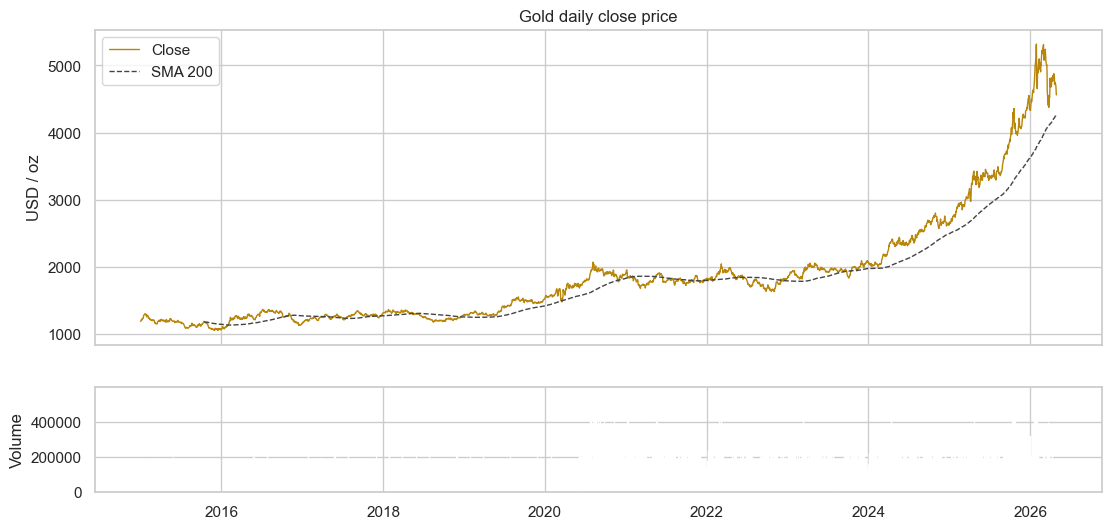

In [7]:
eda = (raw.dropna(subset=["Date", "Close"]).drop_duplicates("Date", keep="last")
          .sort_values("Date").set_index("Date").loc[START_DATE:END_DATE])
eda_ret = np.log(eda["Close"]).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(eda.index, eda["Close"], color="#B8860B", lw=1, label="Close")
axes[0].plot(eda.index, eda["Close"].rolling(200).mean(), color="#444", ls="--", lw=1, label="SMA 200")
axes[0].set_ylabel("USD / oz"); axes[0].set_title("Gold daily close price"); axes[0].legend()
if "Volume" in eda.columns:
    axes[1].bar(eda.index, eda["Volume"], color="#888", width=1.0)
axes[1].set_ylabel("Volume")
save_fig(fig, "01_price_history.png")

**Insight — trend.** The level series is dominated by a long-run upward trend with an acceleration in the latest
years, so the mean is not constant and gold keeps setting new highs. Any later period can therefore trade **above the
range seen in earlier data**. This matters for model design: tree models and scaled-price neural networks cannot
extrapolate beyond the range seen in training, which motivates modelling **returns** instead of price levels for
XGBoost and LSTM. (Section 6.5 confirms this using the validation period only.)

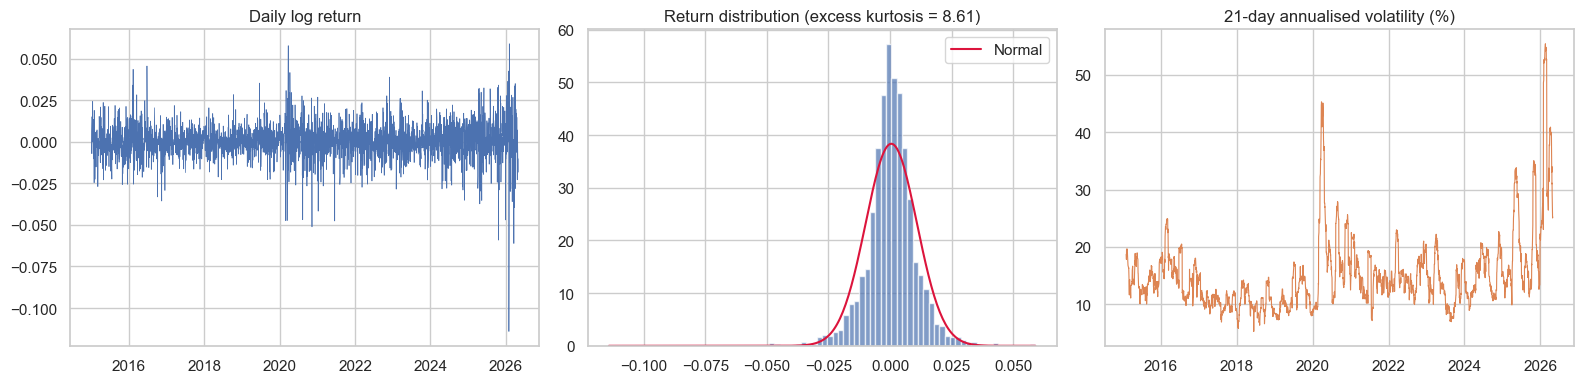

count   2,846.0000
mean        0.0005
std         0.0104
min        -0.1141
25%        -0.0044
50%         0.0005
75%         0.0058
max         0.0589
Skewness -0.617 | Jarque-Bera p-value 0.00e+00


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(eda_ret.index, eda_ret, lw=0.5); axes[0].set_title("Daily log return")
axes[1].hist(eda_ret, bins=80, density=True, alpha=0.7)
x = np.linspace(eda_ret.min(), eda_ret.max(), 300)
axes[1].plot(x, stats.norm.pdf(x, eda_ret.mean(), eda_ret.std()), color="crimson", label="Normal")
axes[1].set_title(f"Return distribution (excess kurtosis = {eda_ret.kurt():.2f})"); axes[1].legend()
vol = eda_ret.rolling(21).std() * np.sqrt(252) * 100
axes[2].plot(vol.index, vol, color="#DD8452", lw=0.8); axes[2].set_title("21-day annualised volatility (%)")
fig.tight_layout()
save_fig(fig, "02_returns_volatility.png")

print(eda_ret.describe().to_string())
print(f"Skewness {eda_ret.skew():.3f} | Jarque-Bera p-value {stats.jarque_bera(eda_ret).pvalue:.2e}")

**Insight — returns.** Log returns fluctuate around zero, have fat tails (positive excess kurtosis, Normality
rejected by Jarque-Bera) and show **volatility clustering** (calm and turbulent regimes). Extreme days are
therefore more frequent than a Gaussian model implies, which inflates squared-error metrics — hence we report
MAE alongside RMSE.

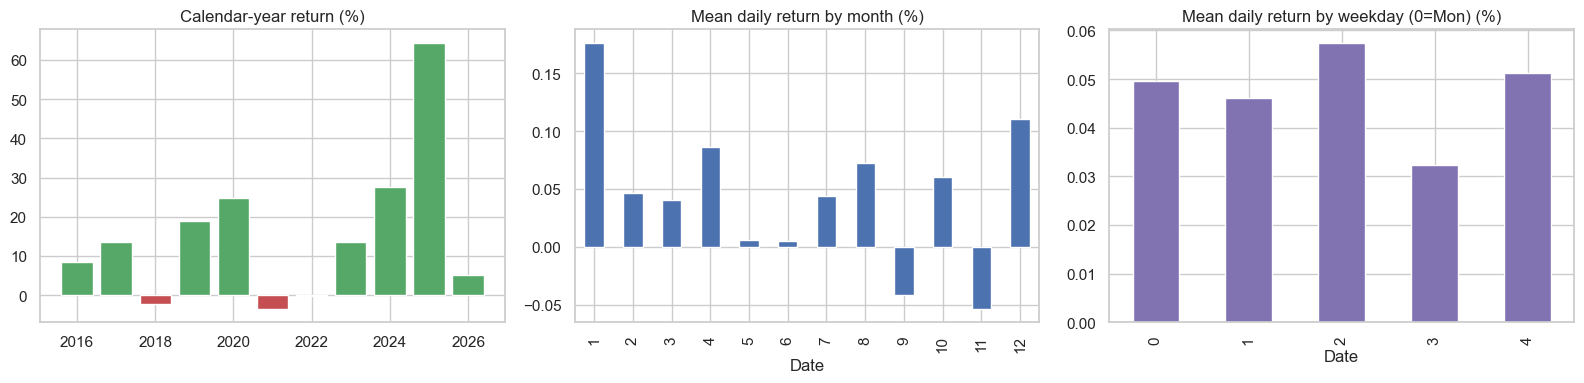

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
yearly = eda["Close"].resample("YE").last().pct_change().dropna() * 100
axes[0].bar(yearly.index.year, yearly.values, color=np.where(yearly.values >= 0, "#55A868", "#C44E52"))
axes[0].set_title("Calendar-year return (%)")
(eda_ret * 100).groupby(eda_ret.index.month).mean().plot.bar(ax=axes[1]); axes[1].set_title("Mean daily return by month (%)")
(eda_ret * 100).groupby(eda_ret.index.dayofweek).mean().plot.bar(ax=axes[2], color="#8172B2")
axes[2].set_title("Mean daily return by weekday (0=Mon) (%)")
fig.tight_layout()
save_fig(fig, "03_seasonal_profile.png")

**Insight — seasonality.** Month-of-year and day-of-week averages are small relative to daily volatility, so there is
no strong calendar seasonality to exploit; a seasonal (SARIMA) term is not justified. Day-of-week is still offered to
XGBoost as a cheap feature.

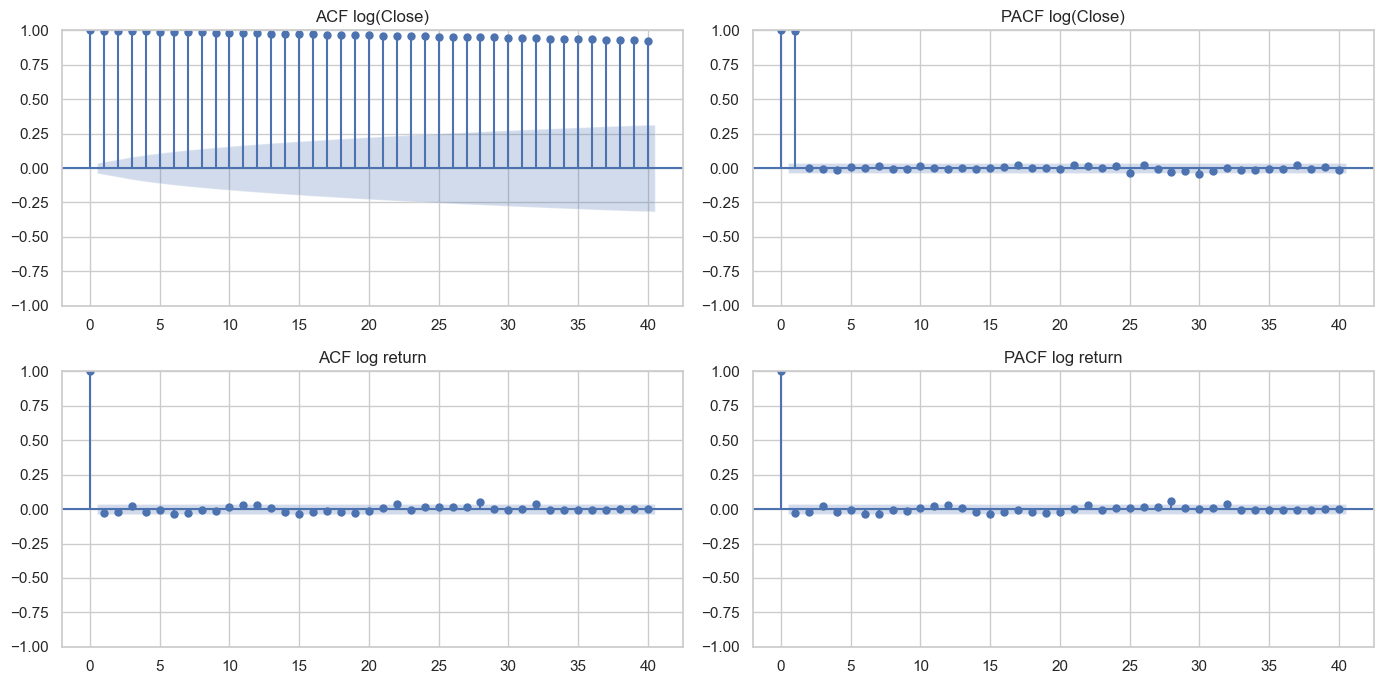

,series,ADF statistic,p-value,lags,critical 5%,stationary (p<0.05)
0,log(Close),1.3250,0.9967,1,-2.8626,False
1,log return,-54.8362,0.0000,0,-2.8626,True


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
plot_acf(np.log(eda["Close"]), lags=40, ax=axes[0, 0]); axes[0, 0].set_title("ACF log(Close)")
plot_pacf(np.log(eda["Close"]), lags=40, ax=axes[0, 1], method="ywm"); axes[0, 1].set_title("PACF log(Close)")
plot_acf(eda_ret, lags=40, ax=axes[1, 0]); axes[1, 0].set_title("ACF log return")
plot_pacf(eda_ret, lags=40, ax=axes[1, 1], method="ywm"); axes[1, 1].set_title("PACF log return")
fig.tight_layout()
save_fig(fig, "04_acf_pacf.png")


def adf_report(series, name):
    stat, p, lags, nobs, crit, _ = adfuller(series.dropna(), autolag="AIC")
    return {"series": name, "ADF statistic": stat, "p-value": p, "lags": lags, "critical 5%": crit["5%"],
            "stationary (p<0.05)": p < 0.05}


display(pd.DataFrame([adf_report(np.log(eda["Close"]), "log(Close)"), adf_report(eda_ret, "log return")]))

**Insight — stationarity & autocorrelation.** The ACF of log price decays extremely slowly and the ADF test does
**not** reject a unit root, whereas log returns are stationary with only weak autocorrelation. This implies
(i) first differencing (`d = 1`) for ARIMA and (ii) that past prices carry little linear information about
tomorrow's change — a naive random-walk forecast will be a hard baseline to beat.

## 6. Data Preparation
The steps below are applied **in this order** (the report follows the same order).

### 6.1 Cleaning
1. Drop rows with an unparseable date.
2. Sort chronologically and drop duplicate dates (keep the last record).
3. Drop rows with a missing or non-positive `Close` — the target cannot be imputed without inventing prices.
4. Fill missing/non-positive `Open`/`High`/`Low` with that day's `Close`.
5. Restrict to the analysis window.

Non-trading days are **not** inserted: forecasting operates on the trading-day sequence.

In [11]:
df = raw.dropna(subset=["Date"]).sort_values("Date")
n_dup = int(df["Date"].duplicated(keep="last").sum())
df = df.drop_duplicates("Date", keep="last")
n_missing_close = int(df["Close"].isna().sum() + (df["Close"] <= 0).sum())
df = df[df["Close"] > 0]
for col in ("Open", "High", "Low"):
    if col in df.columns:
        bad = df[col].isna() | (df[col] <= 0)
        df.loc[bad, col] = df.loc[bad, "Close"]
df = df.set_index("Date").loc[START_DATE:END_DATE]
print(f"Removed {n_dup} duplicate dates and {n_missing_close} invalid closes -> {len(df):,} clean rows "
      f"({df.index.min().date()} to {df.index.max().date()})")
df.to_csv(PROCESSED_DIR / "xauusd_clean.csv")

Removed 0 duplicate dates and 0 invalid closes -> 2,847 clean rows (2015-01-02 to 2026-04-29)


### 6.2 Log-return transformation
`r[t] = ln(Close[t] / Close[t-1])`. Log returns are stationary, scale-free (comparable across price regimes) and
additive over time. They are the modelling target for XGBoost and LSTM; forecasts are converted back to prices with
`Close_hat[t+1] = Close[t] · exp(r_hat[t+1])`.

In [12]:
df["log_return"] = np.log(df["Close"]).diff()
df[["Close", "log_return"]].tail()

,Close,log_return
Date,,
2026-04-23,"4,724.0000",-0.0061
2026-04-24,"4,740.8999",0.0036
2026-04-27,"4,693.7002",-0.0100
2026-04-28,"4,608.3999",-0.0183
2026-04-29,"4,561.5000",-0.0102


### 6.3 Feature engineering (supervised framing without look-ahead)
Each row is a *forecast origin* `t`. Features only use data available at the close of day `t`:

| Feature group | Columns | Rationale |
|---|---|---|
| Lagged returns | `ret_lag_0 … ret_lag_9` | short-term momentum / mean reversion |
| Rolling mean of returns | `ret_mean_5/10/20` | recent drift |
| Rolling std of returns | `ret_std_5/10/20` | volatility regime (clustering seen in EDA) |
| Price vs moving average | `close_sma_ratio_5/10/20` | distance from trend |
| Intraday range | `hl_range = (High−Low)/Close` | intraday uncertainty |
| Open-to-close change | `oc_change` | intraday direction |
| Calendar | `day_of_week` | residual weekday effects |

Targets: `target_return = ln(Close[t+1]/Close[t])` and `target_close = Close[t+1]`. Rows with incomplete rolling
windows (the first 20) and the final row (no next day) are dropped.

In [13]:
def build_feature_frame(data, n_lags=N_LAGS, windows=WINDOWS):
    close, ret = data["Close"], data["log_return"]
    out = pd.DataFrame(index=data.index)
    for k in range(n_lags):
        out[f"ret_lag_{k}"] = ret.shift(k)
    for w in windows:
        out[f"ret_mean_{w}"] = ret.rolling(w).mean()
        out[f"ret_std_{w}"] = ret.rolling(w).std()
        out[f"close_sma_ratio_{w}"] = close / close.rolling(w).mean() - 1
    if {"High", "Low"} <= set(data.columns):
        out["hl_range"] = (data["High"] - data["Low"]) / close
    if "Open" in data.columns:
        out["oc_change"] = close / data["Open"] - 1
    out["day_of_week"] = data.index.dayofweek
    out["close"] = close
    out["target_return"] = np.log(close.shift(-1) / close)
    out["target_close"] = close.shift(-1)
    return out.replace([np.inf, -np.inf], np.nan).dropna()


frame = build_feature_frame(df)
FEATURES = [c for c in frame.columns if c not in ("close", "target_return", "target_close")]

# Leakage check: target_close at origin t must equal Close on the next trading day.
nxt = df["Close"].shift(-1).loc[frame.index]
assert np.allclose(frame["target_close"], nxt), "target misaligned"
print(f"Supervised frame: {frame.shape[0]:,} rows, {len(FEATURES)} features")
frame.head()

Supervised frame: 2,826 rows, 22 features


,ret_lag_0,ret_lag_1,ret_lag_2,ret_lag_3,ret_lag_4,ret_lag_5,ret_lag_6,ret_lag_7,ret_lag_8,ret_lag_9,...,close_sma_ratio_10,ret_mean_20,ret_std_20,close_sma_ratio_20,hl_range,oc_change,day_of_week,close,target_return,target_close
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-02,-0.0018,0.0189,-0.0246,-0.0045,0.0096,-0.0103,-0.0062,0.0054,-0.0004,0.0135,...,-0.0067,0.0037,0.0115,0.0149,0.0142,-0.0062,0,"1,276.2000",-0.0130,"1,259.7000"
2015-02-03,-0.0130,-0.0018,0.0189,-0.0246,-0.0045,0.0096,-0.0103,-0.0062,0.0054,-0.0004,...,-0.0169,0.0023,0.0118,-0.0004,0.0233,-0.0108,1,"1,259.7000",0.0032,"1,263.8000"
2015-02-04,0.0032,-0.0130,-0.0018,0.0189,-0.0246,-0.0045,0.0096,-0.0103,-0.0062,0.0054,...,-0.0114,0.0018,0.0115,0.0011,0.0117,0.0014,2,"1,263.8000",-0.0014,"1,262.0000"
2015-02-05,-0.0014,0.0032,-0.0130,-0.0018,0.0189,-0.0246,-0.0045,0.0096,-0.0103,-0.0062,...,-0.0098,0.0021,0.0113,-0.0024,0.0117,-0.0077,3,"1,262.0000",-0.0225,"1,233.9000"
2015-02-06,-0.0225,-0.0014,0.0032,-0.0130,-0.0018,0.0189,-0.0246,-0.0045,0.0096,-0.0103,...,-0.0273,0.0010,0.0126,-0.0256,0.0321,-0.0246,4,"1,233.9000",0.0056,"1,240.8000"


### 6.4 Chronological train / validation / test split
Random shuffling would leak future information into training. The split is by time:
the **validation** set drives hyperparameter selection and early stopping; the **test** set is used exactly once for
the final comparison.

**Origin vs target dates.** Each row is a forecast *origin* `t`; the value being predicted is the close on the
*next trading day* `t+1`. The table therefore reports both periods: for example, test origins run to the second-to-last
trading day, while the predicted (target) prices run to the last trading day in the data.

,rows,origin start,origin end,target start,target end,min close,max close
train,2260,2015-02-02,2024-01-26,2015-02-03,2024-01-29,"1,050.8000","2,093.1001"
validation,282,2024-01-29,2025-03-12,2024-01-30,2025-03-13,"2,004.3000","2,963.2000"
test,284,2025-03-13,2026-04-28,2025-03-14,2026-04-29,"2,973.6001","5,318.3999"


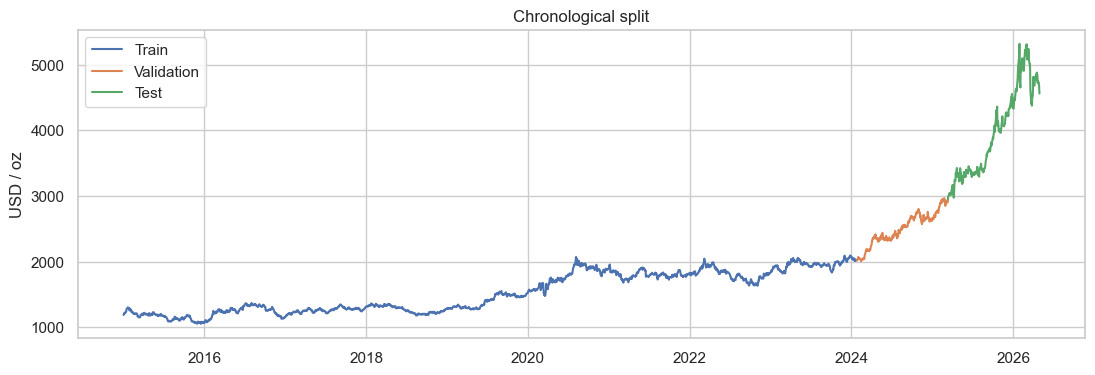

In [14]:
n = len(frame)
n_train, n_val = int(n * TRAIN_FRAC), int(n * VAL_FRAC)
train, val, test = frame.iloc[:n_train], frame.iloc[n_train:n_train + n_val], frame.iloc[n_train + n_val:]
next_trading_day = lambda d: df.index[df.index.get_loc(d) + 1]
split_info = pd.DataFrame({
    "rows": [len(train), len(val), len(test)],
    "origin start": [s.index[0].date() for s in (train, val, test)],
    "origin end": [s.index[-1].date() for s in (train, val, test)],
    "target start": [next_trading_day(s.index[0]).date() for s in (train, val, test)],
    "target end": [next_trading_day(s.index[-1]).date() for s in (train, val, test)],
    "min close": [s["close"].min() for s in (train, val, test)],
    "max close": [s["close"].max() for s in (train, val, test)],
}, index=["train", "validation", "test"])
display(split_info)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["Close"].loc[:train.index[-1]], label="Train")
ax.plot(df["Close"].loc[train.index[-1]:val.index[-1]], label="Validation")
ax.plot(df["Close"].loc[val.index[-1]:], label="Test")
ax.set_title("Chronological split"); ax.set_ylabel("USD / oz"); ax.legend()
save_fig(fig, "05_split.png")

### 6.5 Design checks on training and validation data only
The EDA in Section 5 looked at the full dataset. To make sure no modelling decision depends on the test period,
the decisions are re-derived here **without touching test data**:

1. **Model returns, not price levels**: is the validation price range already outside the training range?
2. **Difference once (ARIMA `d = 1`)**: ADF test on training log prices and training log returns.
3. **No seasonal term (no SARIMA)**: are month-of-year effects in training returns small relative to daily volatility?
4. **Weak linear signal**: Ljung-Box test for autocorrelation in training returns.

In [15]:
tr_close = df["Close"].loc[:train.index[-1]]
tr_ret = df["log_return"].loc[train.index[0]:train.index[-1]].dropna()
checks = pd.DataFrame([
    {"decision": "model returns", "evidence": "share of validation closes above train max (%)",
     "value": float((val["close"] > tr_close.max()).mean() * 100)},
    {"decision": "d = 1", "evidence": "ADF p-value, train log(Close)", "value": float(adfuller(np.log(tr_close))[1])},
    {"decision": "d = 1", "evidence": "ADF p-value, train log return", "value": float(adfuller(tr_ret)[1])},
    {"decision": "no SARIMA", "evidence": "max |mean return by month| / daily std (train)",
     "value": float(tr_ret.groupby(tr_ret.index.month).mean().abs().max() / tr_ret.std())},
    {"decision": "weak linear signal", "evidence": "Ljung-Box p-value, train returns, lag 10",
     "value": float(acorr_ljungbox(tr_ret, lags=[10], return_df=True)["lb_pvalue"].iloc[0])},
])
display(checks)

,decision,evidence,value
0,model returns,share of validation closes above train max (%),91.8440
1,d = 1,"ADF p-value, train log(Close)",0.7900
2,d = 1,"ADF p-value, train log return",0.0000
3,no SARIMA,max |mean return by month| / daily std (train),0.1413
4,weak linear signal,"Ljung-Box p-value, train returns, lag 10",0.3249


**Result.** The design decisions are checked on training and validation data alone (see the table above): whether the
validation period already trades above the training maximum, whether training log prices are non-stationary while
training returns are stationary, and how large monthly effects are relative to one day's volatility. The test period
is not needed for any of these choices.

### 6.6 Standardisation (LSTM only)
Neural networks train best on inputs with zero mean and unit variance. The mean and standard deviation are computed
on **training-period returns only** and then applied to validation and test, so no test statistics leak into the
model. Tree models (XGBoost) are scale-invariant and ARIMA uses the log price directly, so neither is scaled.

In [16]:
train_returns = df["log_return"].loc[:train.index[-1]].dropna()
MU, SIGMA = float(train_returns.mean()), float(train_returns.std())
scaled_returns = (df["log_return"] - MU) / SIGMA
print(f"Train log-return mean = {MU:.6f}, std = {SIGMA:.6f}")

Train log-return mean = 0.000233, std = 0.009272


### 6.7 Sliding windows (LSTM only)
For window length `W`, the input for origin `t` is the sequence of the `W` most recent standardised returns
`[r[t-W+1], …, r[t]]` with shape `(W, 1)`; the target is the standardised `r[t+1]`.

In [17]:
def make_sequences(series, origins, window):
    values = series.to_numpy(dtype=float)
    pos = series.index.get_indexer(origins)
    mask, xs = np.zeros(len(origins), dtype=bool), []
    for i, p in enumerate(pos):
        if p - window + 1 < 0:
            continue
        seg = values[p - window + 1:p + 1]
        if np.isnan(seg).any():
            continue
        mask[i] = True
        xs.append(seg)
    return np.asarray(xs, dtype=np.float32).reshape(-1, window, 1), mask


X_demo, m_demo = make_sequences(scaled_returns, train.index, 30)
print(f"Example: W=30 -> X_train shape {X_demo.shape}, {m_demo.sum()} of {len(train)} origins have a full window")

Example: W=30 -> X_train shape (2250, 30, 1), 2250 of 2260 origins have a full window


## 7. Modeling
### Evaluation helpers
Shared metric functions (formulas are explained in Section 8).

In [18]:
def rmse(y, p): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))
def mae(y, p): return float(np.mean(np.abs(np.asarray(y) - np.asarray(p))))
def mape(y, p): return float(np.mean(np.abs((np.asarray(y) - np.asarray(p)) / np.asarray(y))) * 100)


def directional_accuracy(cur, y, p):
    cur, y, p = map(np.asarray, (cur, y, p))
    true_dir = np.sign(y - cur)
    pred_dir = np.where(np.abs(p - cur) <= 1e-9 * np.abs(cur), 0, np.sign(p - cur))
    valid = true_dir != 0
    return float("nan") if not pred_dir.any() else float(np.mean(true_dir[valid] == pred_dir[valid]) * 100)


def to_price(close, log_ret):
    return np.asarray(close, float) * np.exp(np.asarray(log_ret, float))


y_test, cur_test = test["target_close"].to_numpy(), test["close"].to_numpy()
y_val, cur_val = val["target_close"].to_numpy(), val["close"].to_numpy()
predictions, val_predictions, timings = {}, {}, {}

### 7.1 Model 1 — Naive random walk (baseline)
`Close_hat[t+1] = Close[t]`. Under the efficient-market hypothesis, prices follow approximately a random walk, so
this forecast is optimal when returns are unpredictable. **Any model worth deploying must beat it.**

- **Pros:** zero parameters, zero training cost, surprisingly strong for asset prices.
- **Cons:** never predicts a direction; lags every turning point by one day.

In [19]:
t0 = time.perf_counter()
predictions["Naive"] = cur_test.copy()
val_predictions["Naive"] = cur_val.copy()
timings["Naive"] = time.perf_counter() - t0
print(f"Naive validation RMSE = {rmse(y_val, val_predictions['Naive']):.3f}")

Naive validation RMSE = 24.754


### 7.2 Model 2 — ARIMA(p, d, q)
ARIMA models the differenced series as a linear combination of its own lags (AR, order `p`) and past forecast
errors (MA, order `q`). It is fitted on `log(Close)` so that differences are log returns.

**Procedure**
1. `d`: smallest differencing order for which the ADF test rejects a unit root on the training data.
2. `(p, q)`: grid search over `p, q ∈ {0,1,2,3}`, selecting the lowest **AIC** (penalises extra parameters).
3. Parameters are estimated on the **training period only**, then re-applied (not re-estimated) to the full series to
   produce genuine one-step-ahead forecasts: the forecast for `t+1` conditions only on data up to `t`.

- **Pros:** interpretable, statistically grounded, fast on CPU, few parameters, works on small data.
- **Cons:** linear, assumes constant variance (ignores volatility clustering), no exogenous information.

In [20]:
log_close_train = np.log(df["Close"].loc[:train.index[-1]]).to_numpy()

d, series_d = 0, pd.Series(log_close_train)
while adfuller(series_d.dropna())[1] >= 0.05 and d < 2:
    d, series_d = d + 1, series_d.diff()
print(f"Selected differencing order d = {d}")

t0 = time.perf_counter()
records, best_arima = [], None
for p, q in itertools.product(ARIMA_P, ARIMA_Q):
    try:
        res = ARIMA(log_close_train, order=(p, d, q)).fit()
        records.append({"order": (p, d, q), "AIC": res.aic, "BIC": res.bic})
        if best_arima is None or res.aic < best_arima.aic:
            best_arima = res
    except Exception:
        records.append({"order": (p, d, q), "AIC": np.nan, "BIC": np.nan})
arima_grid = pd.DataFrame(records).sort_values("AIC").reset_index(drop=True)
ARIMA_ORDER = tuple(best_arima.model.order)
display(arima_grid.head(8))
print(best_arima.summary())

Selected differencing order d = 1


,order,AIC,BIC
0,"(0, 1, 0)","-14,865.0393","-14,859.3078"
1,"(0, 1, 1)","-14,863.8996","-14,852.4366"
2,"(1, 1, 0)","-14,863.8851","-14,852.4221"
3,"(0, 1, 3)","-14,862.2834","-14,839.3574"
4,"(3, 1, 0)","-14,862.2561","-14,839.3301"
5,"(2, 1, 0)","-14,862.0691","-14,844.8747"
6,"(0, 1, 2)","-14,862.0265","-14,844.8321"
7,"(1, 1, 1)","-14,861.5222","-14,844.3277"


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2280
Model:                 ARIMA(0, 1, 0)   Log Likelihood                7433.520
Date:                Thu, 17 Sep 2026   AIC                         -14865.039
Time:                        17:21:08   BIC                         -14859.308
Sample:                             0   HQIC                        -14862.949
                               - 2280                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      8.594e-05   1.47e-06     58.606      0.000    8.31e-05    8.88e-05
Ljung-Box (L1) (Q):                   0.90   Jarque-Bera (JB):              1544.14
Prob(Q):                              0.34   Pr

**One-step-ahead forecasts.** The parameters estimated on training data are frozen and re-applied to the full log-price
series with `apply()`. The in-sample prediction at position `k` uses observations up to `k-1` only, so the forecast for
day `t+1` is built from data up to day `t`. Forecasts are transformed back with `exp()`.

In [21]:
log_close_full = np.log(df["Close"]).to_numpy()
one_step = np.asarray(best_arima.apply(log_close_full).predict(start=0, end=len(log_close_full) - 1))
pos_test = df.index.get_indexer(test.index) + 1
pos_val = df.index.get_indexer(val.index) + 1
arima_name = f"ARIMA{ARIMA_ORDER}"
predictions[arima_name] = np.exp(one_step[pos_test])
val_predictions[arima_name] = np.exp(one_step[pos_val])
timings[arima_name] = time.perf_counter() - t0
print(f"{arima_name}: validation RMSE = {rmse(y_val, val_predictions[arima_name]):.3f} | {timings[arima_name]:.1f}s")

ARIMA(0, 1, 0): validation RMSE = 24.754 | 4.4s


**Residual diagnostics.** A well-specified ARIMA leaves residuals that behave like white noise. The Ljung-Box test
checks for remaining autocorrelation (H0: no autocorrelation up to lag k).

,lb_stat,lb_pvalue
5,5.1817,0.3941
10,11.5280,0.3179
20,27.1419,0.1313


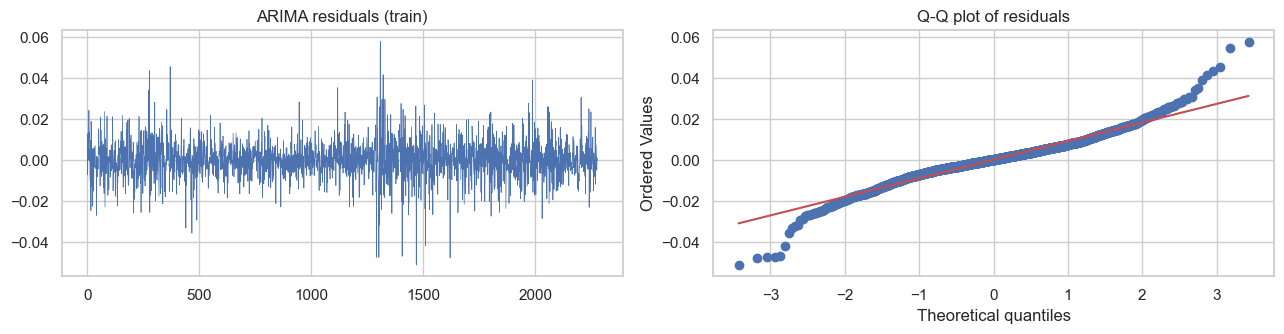

In [22]:
resid = pd.Series(best_arima.resid[d + 1:])
display(acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(resid.values, lw=0.5); axes[0].set_title("ARIMA residuals (train)")
stats.probplot(resid, dist="norm", plot=axes[1]); axes[1].set_title("Q-Q plot of residuals")
fig.tight_layout()
save_fig(fig, "06_arima_residuals.png")

### 7.3 Model 3 — XGBoost on engineered features
Gradient boosting builds an ensemble of shallow regression trees sequentially, each tree fitting the residual errors
of the previous ones. Target: next-day log return (see 6.2); price is reconstructed afterwards.

**Hyperparameter tuning (grid search on the validation set)**

| Parameter | Values | Role |
|---|---|---|
| `max_depth` | 2, 3, 5 | tree complexity (interaction depth) |
| `learning_rate` | 0.01, 0.05 | shrinkage per tree |
| `min_child_weight` | 1, 5 | minimum hessian per leaf (regularisation) |
| `subsample`, `colsample_bytree` | 0.8 | row / column subsampling (variance reduction) |
| `n_estimators` | up to 2000 with early stopping (50 rounds) | number of trees |

Selection criterion: validation **price** RMSE.

**Boosting rounds.** XGBoost's `best_iteration` is a **zero-based** index. A model with `best_iteration = k` predicts
with the first `k + 1` boosting rounds (trees), so the table reports `boosting_rounds = best_iteration + 1`.

- **Pros:** captures non-linear interactions, robust to feature scale, fast on CPU, feature importance for insight.
- **Cons:** cannot extrapolate beyond training targets (mitigated by predicting returns), needs manual feature
  engineering, no native notion of temporal order.

In [23]:
t0 = time.perf_counter()
records, best_xgb, best_score = [], None, np.inf
keys = list(XGB_GRID)
for values in itertools.product(*(XGB_GRID[k] for k in keys)):
    params = dict(zip(keys, values))
    model = XGBRegressor(n_estimators=2000, early_stopping_rounds=50, objective="reg:squarederror",
                         tree_method="hist", random_state=SEED, n_jobs=-1, **params)
    model.fit(train[FEATURES], train["target_return"], eval_set=[(val[FEATURES], val["target_return"])], verbose=False)
    score = rmse(y_val, to_price(cur_val, model.predict(val[FEATURES])))
    records.append({**params, "best_iteration": model.best_iteration, "boosting_rounds": model.best_iteration + 1,
                    "val_RMSE": score})
    if score < best_score:
        best_score, best_xgb, XGB_PARAMS = score, model, params
xgb_grid = pd.DataFrame(records).sort_values("val_RMSE").reset_index(drop=True)
display(xgb_grid.head(8))

predictions["XGBoost"] = to_price(cur_test, best_xgb.predict(test[FEATURES]))
val_predictions["XGBoost"] = to_price(cur_val, best_xgb.predict(val[FEATURES]))
timings["XGBoost"] = time.perf_counter() - t0
print(f"Best XGBoost params: {XGB_PARAMS} | best_iteration={best_xgb.best_iteration} (zero-based) -> "
      f"{best_xgb.best_iteration + 1} boosting rounds | val RMSE {best_score:.3f} | {timings['XGBoost']:.1f}s")

,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,best_iteration,boosting_rounds,val_RMSE
0,5,0.0500,1,0.8000,0.8000,30,31,24.6743
1,5,0.0500,5,0.8000,0.8000,22,23,24.6746
2,5,0.0100,5,0.8000,0.8000,42,43,24.6769
3,5,0.0100,1,0.8000,0.8000,33,34,24.6793
4,3,0.0500,1,0.8000,0.8000,29,30,24.6811
5,2,0.0500,1,0.8000,0.8000,3,4,24.6894
6,2,0.0100,1,0.8000,0.8000,3,4,24.6905
7,3,0.0500,5,0.8000,0.8000,3,4,24.6916


Best XGBoost params: {'max_depth': 5, 'learning_rate': 0.05, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.8} | best_iteration=30 (zero-based) -> 31 boosting rounds | val RMSE 24.674 | 1.2s


**Feature importance.** Gain-based importance of the selected XGBoost model shows which engineered features the trees
used most. A nearly uniform profile means no single feature carries a strong signal.

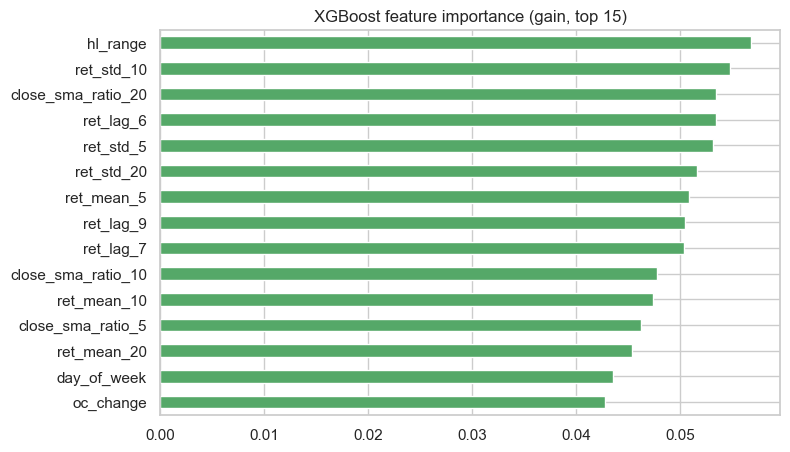

In [24]:
importance = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importance.head(15)[::-1].plot.barh(ax=ax, color="#55A868"); ax.set_title("XGBoost feature importance (gain, top 15)")
save_fig(fig, "07_xgb_feature_importance.png")

### 7.4 Model 4 — LSTM (PyTorch)
A Long Short-Term Memory network processes the return window step by step. Its input, forget and output gates let it
retain or discard information across time steps, alleviating the vanishing-gradient problem of plain RNNs.

**Architecture:** `LSTM(input=1, hidden=H, layers=L, dropout) → Dropout(0.2) → Linear(H → 1)` on the last hidden state.

**Training:** Adam (lr = 1e-3), MSE loss, batch 64, gradient clipping (norm 1.0), up to 100 epochs, early stopping
with patience 10 on validation loss, best weights restored.

**Hyperparameter tuning (grid on validation price RMSE):** window `W ∈ {30, 60}`, hidden units `H ∈ {32, 64}`,
layers `L ∈ {1, 2}` → 8 configurations. Sizes are deliberately small for ~2,300 training samples and 6 GB VRAM.

- **Pros:** learns non-linear temporal dependencies directly from sequences, no manual lag engineering.
- **Cons:** data-hungry, many parameters for a small dataset (overfitting risk), sensitive to initialisation and
  hyperparameters, slowest to train, least interpretable.

In [25]:
class LSTMRegressor(nn.Module):
    def __init__(self, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(self.dropout(out[:, -1, :])).squeeze(-1)


def train_lstm(model, X_tr, y_tr, X_va, y_va):
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)), batch_size=LSTM_BATCH,
                        shuffle=True, generator=torch.Generator().manual_seed(SEED))
    Xv, yv = torch.from_numpy(X_va).to(DEVICE), torch.from_numpy(y_va).to(DEVICE)
    model.to(DEVICE)
    opt, loss_fn = torch.optim.Adam(model.parameters(), lr=LSTM_LR), nn.MSELoss()
    best, best_state, wait, hist = np.inf, None, 0, []
    for epoch in range(1, LSTM_EPOCHS + 1):
        model.train(); total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            total += loss.item() * len(xb)
        model.eval()
        with torch.no_grad():
            vloss = loss_fn(model(Xv), yv).item()
        hist.append({"epoch": epoch, "train_loss": total / len(loader.dataset), "val_loss": vloss})
        if vloss < best - 1e-6:
            best, best_state, wait = vloss, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= LSTM_PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)


def lstm_predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.from_numpy(X).to(DEVICE)).cpu().numpy() * SIGMA + MU


scale = lambda r: ((np.asarray(r, dtype=np.float32) - MU) / SIGMA).astype(np.float32)

t0 = time.perf_counter()
records, best_lstm, best_score = [], None, np.inf
for W, H, L in itertools.product(LSTM_GRID["window"], LSTM_GRID["hidden_size"], LSTM_GRID["num_layers"]):
    torch.manual_seed(SEED)
    X_tr, m_tr = make_sequences(scaled_returns, train.index, W)
    X_va, m_va = make_sequences(scaled_returns, val.index, W)
    model, hist = train_lstm(LSTMRegressor(H, L, LSTM_DROPOUT), X_tr, scale(train["target_return"].to_numpy()[m_tr]),
                             X_va, scale(val["target_return"].to_numpy()[m_va]))
    score = rmse(y_val[m_va], to_price(cur_val[m_va], lstm_predict(model, X_va)))
    records.append({"window": W, "hidden_size": H, "num_layers": L, "epochs": len(hist),
                    "best_val_loss": hist["val_loss"].min(), "val_RMSE": score})
    print(f"W={W:>2} H={H:>2} L={L} -> epochs={len(hist):>3}, val RMSE={score:.3f}")
    if score < best_score:
        best_score, best_lstm, LSTM_PARAMS, lstm_history = score, model, {"window": W, "hidden_size": H, "num_layers": L}, hist
lstm_grid = pd.DataFrame(records).sort_values("val_RMSE").reset_index(drop=True)
display(lstm_grid)

X_te, m_te = make_sequences(scaled_returns, test.index, LSTM_PARAMS["window"])
X_va, m_va = make_sequences(scaled_returns, val.index, LSTM_PARAMS["window"])
assert m_te.all() and m_va.all()
predictions["LSTM"] = to_price(cur_test, lstm_predict(best_lstm, X_te))
val_predictions["LSTM"] = to_price(cur_val, lstm_predict(best_lstm, X_va))
timings["LSTM"] = time.perf_counter() - t0
print(f"Best LSTM: {LSTM_PARAMS} | val RMSE {best_score:.3f} | total tuning time {timings['LSTM']:.1f}s on {DEVICE}")

W=30 H=32 L=1 -> epochs= 28, val RMSE=24.630


W=30 H=32 L=2 -> epochs= 12, val RMSE=24.626


W=30 H=64 L=1 -> epochs= 12, val RMSE=24.606


W=30 H=64 L=2 -> epochs= 12, val RMSE=24.584


W=60 H=32 L=1 -> epochs= 22, val RMSE=24.631


W=60 H=32 L=2 -> epochs= 11, val RMSE=24.650


W=60 H=64 L=1 -> epochs= 39, val RMSE=24.596


W=60 H=64 L=2 -> epochs= 11, val RMSE=24.587


,window,hidden_size,num_layers,epochs,best_val_loss,val_RMSE
0,30,64,2,12,1.0985,24.5843
1,60,64,2,11,1.0986,24.5866
2,60,64,1,39,1.1008,24.5959
3,30,64,1,12,1.1008,24.6062
4,30,32,2,12,1.1025,24.6258
5,30,32,1,28,1.1034,24.6298
6,60,32,1,22,1.1036,24.6309
7,60,32,2,11,1.1049,24.6499


Best LSTM: {'window': 30, 'hidden_size': 64, 'num_layers': 2} | val RMSE 24.584 | total tuning time 17.9s on cuda


**Learning curve.** Training and validation loss per epoch for the selected configuration. The epoch with the lowest
validation loss is the one whose weights were restored by early stopping.

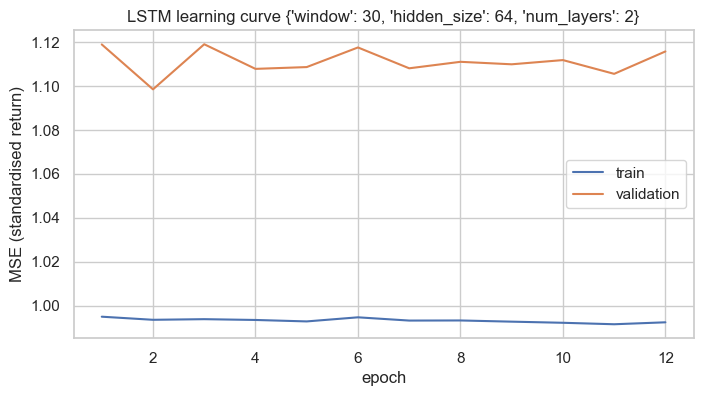

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_history["epoch"], lstm_history["train_loss"], label="train")
ax.plot(lstm_history["epoch"], lstm_history["val_loss"], label="validation")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (standardised return)"); ax.set_title(f"LSTM learning curve {LSTM_PARAMS}"); ax.legend()
save_fig(fig, "08_lstm_learning_curve.png")

## 8. Evaluation
### 8.1 Metrics
With `y` the actual next-day close, `ŷ` the forecast and `n` test days:

- **RMSE** $=\sqrt{\frac{1}{n}\sum (y_i-\hat y_i)^2}$ — error in USD/oz; squaring penalises large misses (important
  for risk management). Primary metric: **validation RMSE selects the model, test RMSE reports its performance.**
- **MAE** $=\frac{1}{n}\sum |y_i-\hat y_i|$ — typical absolute miss in USD/oz, robust to outliers.
- **MAPE** $=\frac{100}{n}\sum \left|\frac{y_i-\hat y_i}{y_i}\right|$ — scale-free percentage error, comparable across
  price regimes (safe because gold prices are strictly positive).
- **Directional accuracy** — % of days where `sign(ŷ[t+1] − y[t]) = sign(y[t+1] − y[t])`; relevant for trading
  decisions. Undefined for the naive model, which never predicts a move.
- **Diebold-Mariano test** — tests H0 "two forecasts have equal expected squared error" (with the
  Harvey-Leybourne-Newbold correction). p < 0.05 means the difference versus the naive baseline is significant.

In [27]:
def diebold_mariano(y, p1, p2, h=1):
    d_ = (np.asarray(y) - np.asarray(p1)) ** 2 - (np.asarray(y) - np.asarray(p2)) ** 2
    n_ = len(d_)
    dm = d_.mean() / np.sqrt(d_.var() / n_)
    dm *= np.sqrt((n_ + 1 - 2 * h + h * (h - 1) / n_) / n_)
    return dm, 2 * stats.t.sf(abs(dm), df=n_ - 1)


rows = {}
for name, pred in predictions.items():
    row = {"Val RMSE": rmse(y_val, val_predictions[name]), "Test RMSE": rmse(y_test, pred), "Test MAE": mae(y_test, pred),
           "Test MAPE (%)": mape(y_test, pred), "Directional Acc. (%)": directional_accuracy(cur_test, y_test, pred),
           "Time (s)": timings[name]}
    if name != "Naive":
        row["DM stat vs Naive"], row["DM p-value"] = diebold_mariano(y_test, pred, predictions["Naive"])
    rows[name] = row
metrics = pd.DataFrame(rows).T.sort_values("Val RMSE")  # ordered by the selection criterion
metrics["RMSE vs Naive (%)"] = (metrics["Test RMSE"] / metrics.loc["Naive", "Test RMSE"] - 1) * 100
display(metrics)

metrics.round(4).to_csv(RESULTS_DIR / "metrics.csv")
# Each forecast made at origin t predicts the close of the next trading day; keep both dates explicit.
test_target_dates = df.index[df.index.get_indexer(test.index) + 1]
pd.DataFrame({"origin_date": test.index, "target_date": test_target_dates, "actual_next_close": y_test,
              **predictions}).to_csv(RESULTS_DIR / "test_predictions.csv", index=False)
print(f"Test origins: {test.index[0].date()} to {test.index[-1].date()} | "
      f"predicted (target) closes: {test_target_dates[0].date()} to {test_target_dates[-1].date()}")

,Val RMSE,Test RMSE,Test MAE,Test MAPE (%),Directional Acc. (%),Time (s),DM stat vs Naive,DM p-value,RMSE vs Naive (%)
LSTM,24.5843,75.6529,49.6028,1.2066,56.3830,17.8650,-0.9601,0.3378,-0.2042
XGBoost,24.6743,75.5453,49.7585,1.2085,57.4468,1.2364,-0.2780,0.7812,-0.3461
"ARIMA(0, 1, 0)",24.7541,75.8077,49.8162,1.2122,NaN,4.4035,0.0266,0.9788,0.0000
Naive,24.7541,75.8077,49.8162,1.2122,NaN,0.0001,NaN,NaN,0.0000


Test origins: 2025-03-13 to 2026-04-28 | predicted (target) closes: 2025-03-14 to 2026-04-29


Bar charts of the three error metrics on the test set make the (small) differences between models visible.

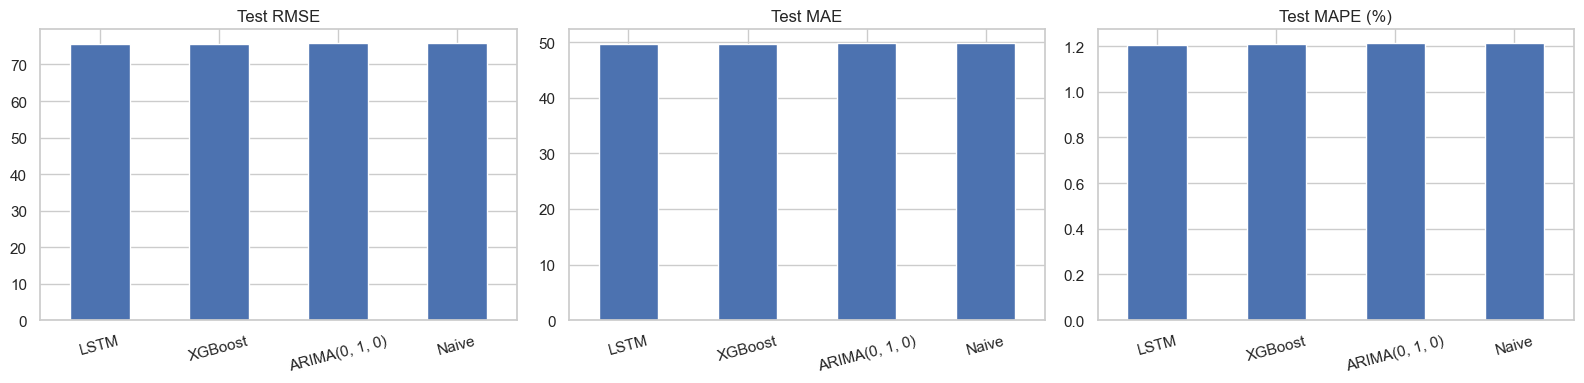

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Test RMSE", "Test MAE", "Test MAPE (%)"]):
    metrics[col].plot.bar(ax=ax, color="#4C72B0"); ax.set_title(col); ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
save_fig(fig, "09_metric_comparison.png")

### 8.2 Forecasts on the test period
Forecasts are plotted on their **target dates** (the day whose close is predicted), not on the origin dates.

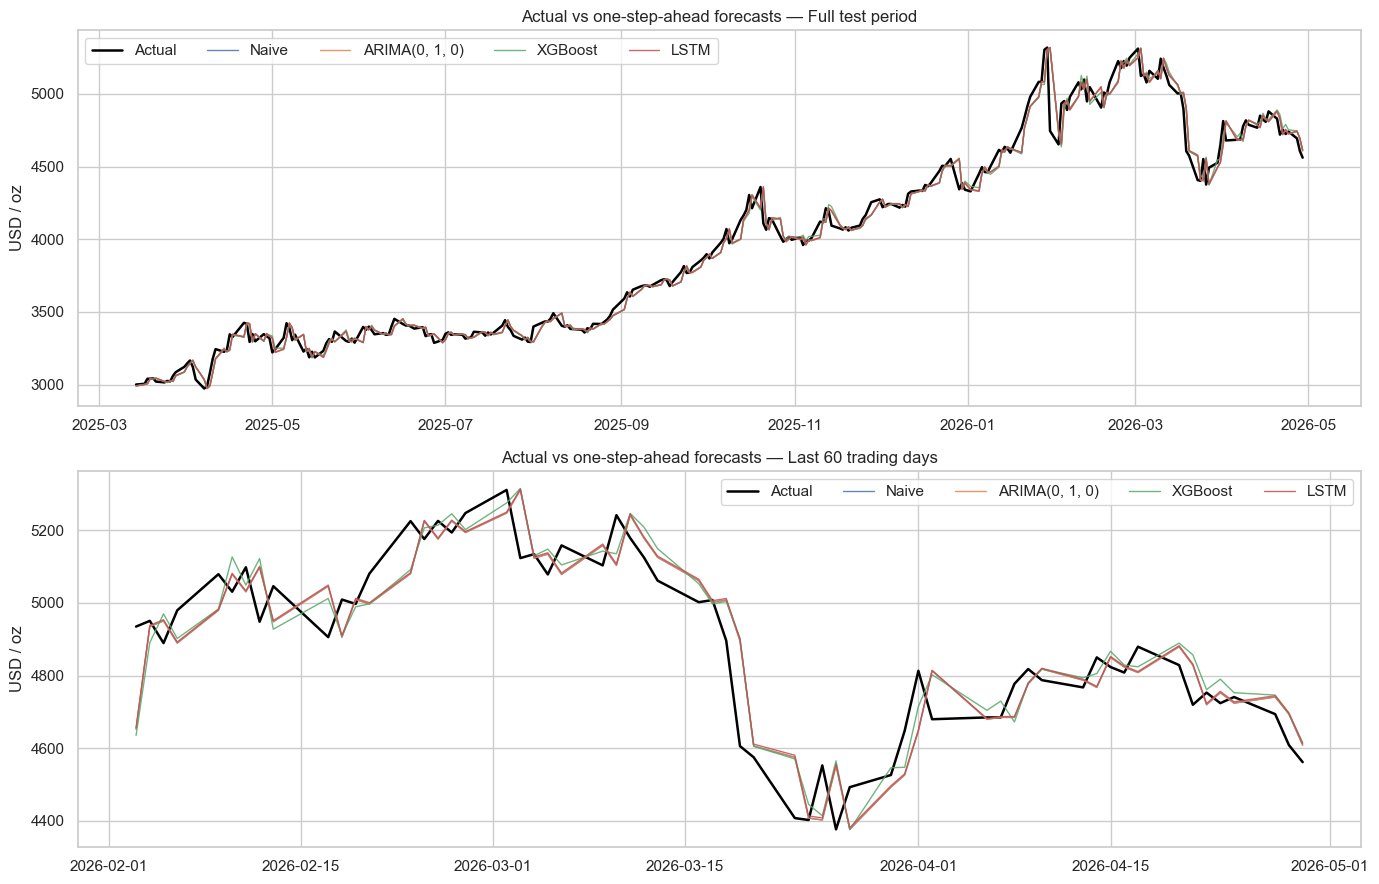

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, sl, title in [(axes[0], slice(None), "Full test period"), (axes[1], slice(-60, None), "Last 60 trading days")]:
    ax.plot(test_target_dates[sl], y_test[sl], color="black", lw=1.8, label="Actual")
    for name, pred in predictions.items():
        ax.plot(test_target_dates[sl], pred[sl], lw=1, alpha=0.85, label=name)
    ax.set_title(f"Actual vs one-step-ahead forecasts — {title}"); ax.set_ylabel("USD / oz"); ax.legend(ncol=5)
fig.tight_layout()
save_fig(fig, "10_test_predictions.png")

**Forecast errors.** Error over time shows when models miss (large shocks); the histogram compares error distributions.

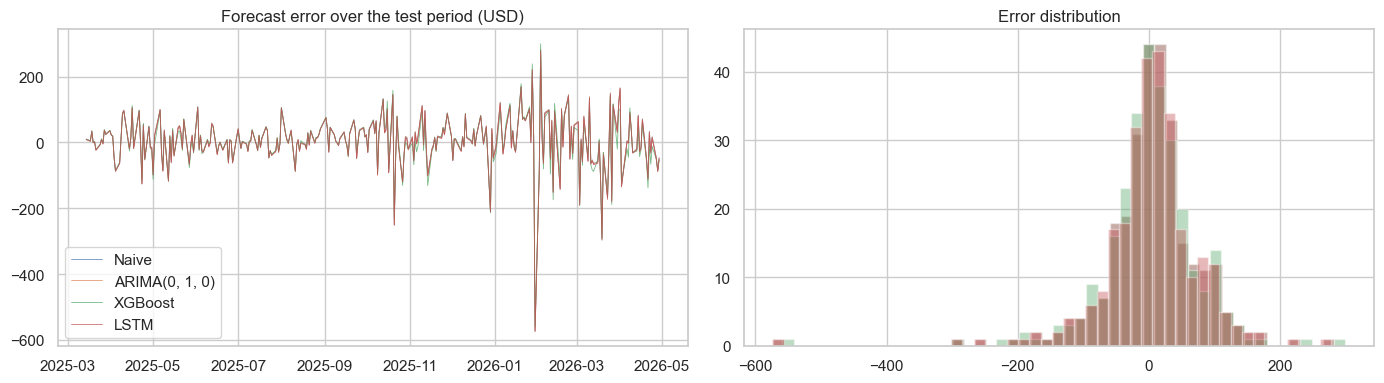

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, pred in predictions.items():
    err = y_test - pred
    axes[0].plot(test_target_dates, err, lw=0.6, alpha=0.8, label=name)
    axes[1].hist(err, bins=50, alpha=0.4, label=name)
axes[0].set_title("Forecast error over the test period (USD)"); axes[1].set_title("Error distribution"); axes[0].legend()
fig.tight_layout()
save_fig(fig, "11_residuals.png")

### 8.3 Model selection and conclusions
The best model is selected by **validation RMSE**, so the test set is never used to choose a model; its test metrics
are then reported as an unbiased estimate. The cell also states whether any model significantly beats the naive
baseline on the test set. Interpretation guidelines used in the report:

- If no model has a DM p-value < 0.05, the honest conclusion is that next-day gold prices are **not meaningfully
  predictable** from price history alone (consistent with weak-form market efficiency and with Makridakis et al.,
  2018); the cheapest adequate model (Naive / ARIMA) is then recommended.
- A model with lower RMSE but higher time cost is recommended only if its improvement is significant.

In [31]:
best_name = metrics["Val RMSE"].idxmin()
best = metrics.loc[best_name]
print(f"Selected model (lowest validation RMSE = {best['Val RMSE']:.3f}): {best_name}")
print(f"  Test RMSE {best['Test RMSE']:.2f} | MAE {best['Test MAE']:.2f} | MAPE {best['Test MAPE (%)']:.3f}% "
      f"| {best['RMSE vs Naive (%)']:+.2f}% RMSE vs Naive")
significant = metrics.drop(index="Naive")
significant = significant[(significant["DM p-value"] < 0.05) & (significant["RMSE vs Naive (%)"] < 0)]
if significant.empty:
    print("No model beats the naive random walk with statistical significance (DM p < 0.05).")
else:
    print("Significantly better than Naive:", ", ".join(significant.index))

summary = {
    "data_file": DATA_FILE.name, "clean_rows": len(df), "supervised_rows": len(frame),
    "split": split_info.astype(str).to_dict(), "arima_order": ARIMA_ORDER, "xgboost_params": XGB_PARAMS,
    "xgboost_best_iteration": int(best_xgb.best_iteration), "xgboost_boosting_rounds": int(best_xgb.best_iteration) + 1,
    "lstm_params": LSTM_PARAMS, "device": DEVICE,
    "selection_criterion": "validation RMSE", "best_model": best_name, "metrics": metrics.round(4).to_dict(orient="index"),
}
(RESULTS_DIR / "run_summary.json").write_text(json.dumps(summary, indent=2, default=str))
best_xgb.save_model(MODELS_DIR / "xgboost.json")
torch.save({"state_dict": best_lstm.state_dict(), "params": LSTM_PARAMS, "mu": MU, "sigma": SIGMA}, MODELS_DIR / "lstm.pt")
print(f"Saved metrics, predictions, run summary and models to {RESULTS_DIR.name}/ and {MODELS_DIR.name}/")

Selected model (lowest validation RMSE = 24.584): LSTM
  Test RMSE 75.65 | MAE 49.60 | MAPE 1.207% | -0.20% RMSE vs Naive
No model beats the naive random walk with statistical significance (DM p < 0.05).
Saved metrics, predictions, run summary and models to results/ and models/


## 9. Closing Notes
- All four solution statements were implemented, tuned and selected on validation data, and evaluated once on the
  same untouched, chronologically later test set.
- The full discussion is in `reports/laporan.md`; figures are saved in `reports/figures/`.
- Limitations: univariate price history only (no macro drivers such as real yields, USD index or central-bank
  purchases), a single test period, and one-step-ahead horizon. These are natural extensions for future work.